In [10]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set_style("whitegrid")

# Load Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Handle missing values
df['Age'].fillna(df['Age'].mean(), inplace=True)


C:\Users\junai\AppData\Local\Temp\ipykernel_3356\2261442811.py:15: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].mean(), inplace=True)


0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

C:\Users\junai\AppData\Local\Temp\ipykernel_3356\1589846336.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Survived', data=df, palette=['red','green'])


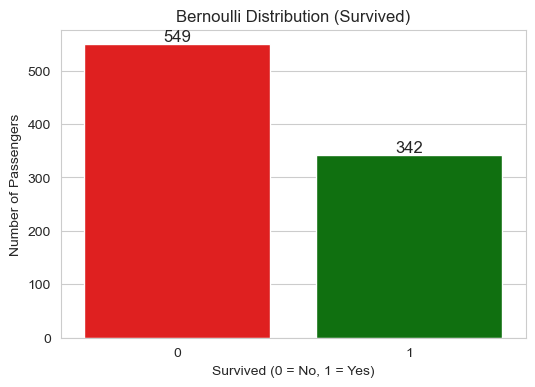

In [19]:
# 1️⃣ Bernoulli Distribution (Survived) with counts
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
ax = sns.countplot(x='Survived', data=df, palette=['red','green'])

# Add numeric counts on top of bars
for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(count, (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.title("Bernoulli Distribution (Survived)")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

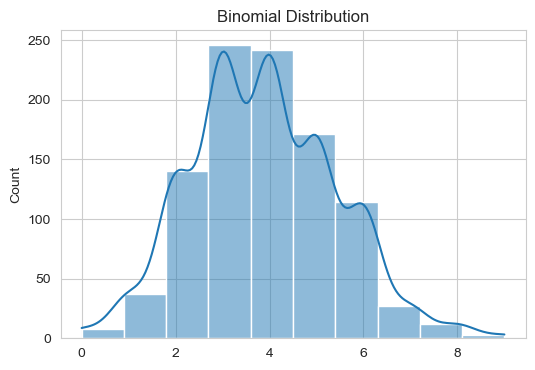

In [20]:
# 2️⃣ Binomial Distribution
p = df['Survived'].mean()          # Probability of survival ≈ 0.38
data = np.random.binomial(10, p, 1000)  # Simulate 1000 experiments of 10 passengers

plt.figure(figsize=(6,4))
sns.histplot(data, bins=10, kde=True)
plt.title("Binomial Distribution")
plt.show()

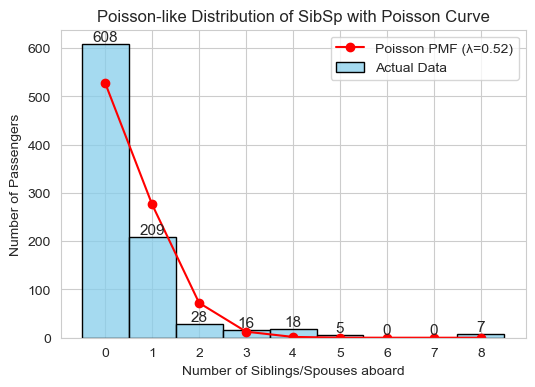

In [22]:
# 3️⃣ Poisson-like Distribution (SibSp) models count data for rare events.
from scipy.stats import poisson
import numpy as np

# Column and its mean
sibsp_counts = df['SibSp']
mu = sibsp_counts.mean()  # average number of siblings/spouses

# X values (0 to max SibSp)
x = np.arange(0, sibsp_counts.max()+1)

# Theoretical Poisson PMF
poisson_pmf = poisson.pmf(x, mu) * len(sibsp_counts)  # scale to match histogram counts

# Plot histogram
plt.figure(figsize=(6,4))
ax = sns.histplot(sibsp_counts, bins=range(sibsp_counts.max()+2), discrete=True, color='skyblue', edgecolor='black', label='Actual Data')

# Overlay Poisson curve
plt.plot(x, poisson_pmf, 'o-', color='red', label=f'Poisson PMF (λ={mu:.2f})')

# Add numeric counts on top of bars
for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(count, (p.get_x() + 0.5, p.get_height()), ha='center', va='bottom', fontsize=11)

plt.title("Poisson-like Distribution of SibSp with Poisson Curve")
plt.xlabel("Number of Siblings/Spouses aboard")
plt.ylabel("Number of Passengers")
plt.xticks(range(sibsp_counts.max()+1))
plt.legend()
plt.show()

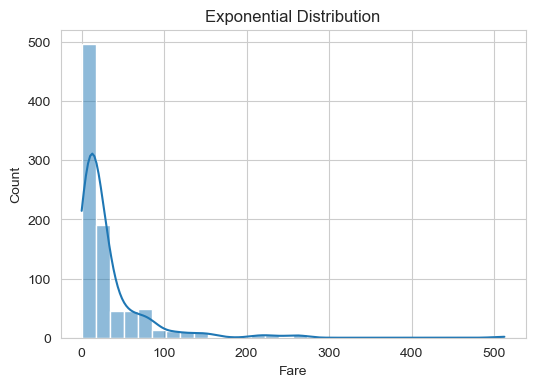

In [14]:
# 4️⃣ Exponential Distribution (Fare)
plt.figure(figsize=(6,4))
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title("Exponential Distribution")
plt.show()

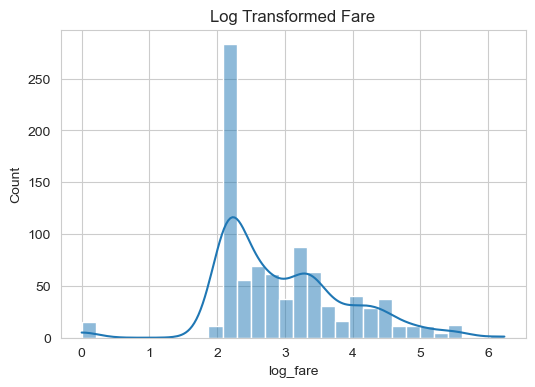

In [15]:
# 5️⃣ Log Transformation
df['log_fare'] = np.log(df['Fare'] + 1)

plt.figure(figsize=(6,4))
sns.histplot(df['log_fare'], bins=30, kde=True)
plt.title("Log Transformed Fare")
plt.show()

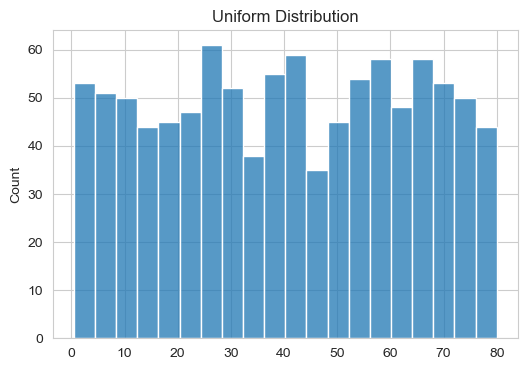

In [16]:
# 6️⃣ Uniform Distribution
uniform_data = np.random.uniform(df['Age'].min(), df['Age'].max(), 1000)

plt.figure(figsize=(6,4))
sns.histplot(uniform_data, bins=20)
plt.title("Uniform Distribution")
plt.show()

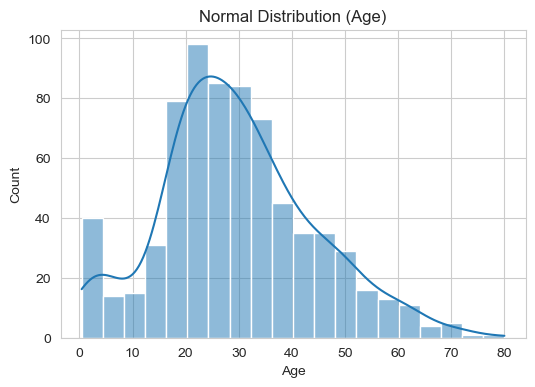

In [17]:
# 7️⃣ Normal Distribution (Age)
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Normal Distribution (Age)")
plt.show()

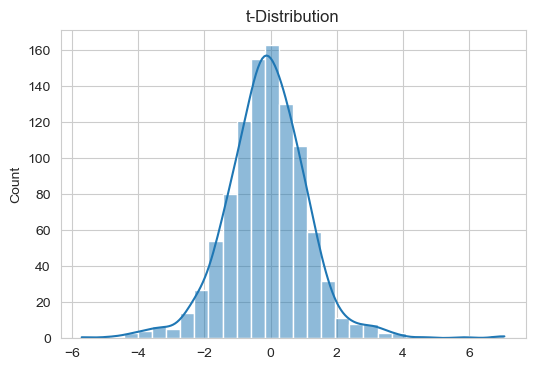

In [18]:
# 8️⃣ t-Distribution
t_data = stats.t.rvs(df=5, size=1000)

plt.figure(figsize=(6,4))
sns.histplot(t_data, bins=30, kde=True)
plt.title("t-Distribution")
plt.show()